# Lab 7

Leonid Zinatullin

In [2]:
import time

import numpy as np
import numpy.typing
from typing import Tuple

import matplotlib.pyplot as plt


import nidaqmx
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE, LineGrouping
from nidaqmx.errors import DaqError


import scipy as sp

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [ ]:
device_name = '/Dev7'

In [18]:
import nidaqmx
from nidaqmx.constants import AcquisitionType, Edge

device = "Dev7"
ai_chan = f"{device}/ai0"
trig_src = f"/{device}/PFI0"   # external trigger line

rate = 10000        # Hz
samples = 1000      # samples to capture per trigger

print("Arming on each trigger. Ctrl+C to stop.")
try:
    while True:
        with nidaqmx.Task() as t:
            t.ai_channels.add_ai_voltage_chan(
                device_name + "/ai0",
                terminal_config=TerminalConfiguration.RSE,
                min_val=-5,
                max_val=5
            )

            t.timing.cfg_samp_clk_timing(
                rate=rate,
                sample_mode=AcquisitionType.FINITE,
                samps_per_chan=samples
            )

            # If your line is idle-high and the event pulls low, use FALLING
            t.triggers.start_trigger.cfg_dig_edge_start_trig(
                trigger_source=trig_src,
                trigger_edge=Edge.FALLING
            )

            t.start()

            data = t.read(number_of_samples_per_channel=samples, timeout=10.0)

        # "running buffer" = you process/store each chunk here
        # e.g. append to a list, write to file, push to queue, etc.
        print(f"Got {len(data)} samples. First={data[:10]}")

except KeyboardInterrupt:
    pass


Arming on each trigger. Ctrl+C to stop.
Got 1000 samples. First=[1.4875744161715587, 1.487903406657894, 1.487738911414662, 1.4880679019012548, 1.4883968923883635, 1.4882323971447449, 1.4883968923883635, 1.4883968923883635, 1.4880679019012548, 1.4880679019012548]
Got 1000 samples. First=[1.4880679019012548, 1.4875744161715587, 1.4826395589383023, 1.4834620351358103, 1.488890378119993, 1.4893838638527832, 1.4859294637476101, 1.4818170827440036, 1.4880679019012548, 1.488890378119993]
Got 1000 samples. First=[1.488561387632111, 1.4882323971447449, 1.488561387632111, 1.4880679019012548, 1.488561387632111, 1.4890548733641273, 1.4890548733641273, 1.488890378119993, 1.4887258828759875, 1.487903406657894]
Got 1000 samples. First=[1.4882323971447449, 1.487903406657894, 1.487903406657894, 1.4874099209285843, 1.4883968923883635, 1.488890378119993, 1.4882323971447449, 1.488890378119993, 1.4882323971447449, 1.4880679019012548]
Got 1000 samples. First=[1.4880679019012548, 1.4875744161715587, 1.487409

DaqReadError: Some or all of the samples requested have not yet been acquired.

To wait for the samples to become available use a longer read timeout or read later in your program. To make the samples available sooner, increase the sample rate. If your task uses a start trigger, make sure that your start trigger is configured correctly. It is also possible that you configured the task for external timing, and no clock was supplied. If this is the case, supply an external clock.

Property: DAQmx_Read_RelativeTo
Corresponding Value: DAQmx_Val_CurrReadPos
Property: DAQmx_Read_Offset
Corresponding Value: 0

Task Name: _unnamedTask<F5>

Status Code: -200284

In [12]:
import nidaqmx
from nidaqmx.constants import AcquisitionType, Edge
import numpy as np
import matplotlib.pyplot as plt

device = "Dev7"
ai_chan = f"{device}/ai0"
trig_src = f"/{device}/PFI0"

rate = 10000
samples = 1000

# ---------- plot setup ----------
x = np.arange(samples) / rate

fig, ax = plt.subplots()
ax.set_title("AI0: Current vs Previous Buffer")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")

prev = np.zeros(samples)
cur  = np.zeros(samples)

(line_prev,) = ax.plot(x, prev, label="Previous")
(line_cur,)  = ax.plot(x, cur,  label="Current")
ax.legend()

display(fig)

print("Waiting for triggers… Ctrl+C to stop")

try:
    while True:
        # --- one triggered acquisition (USB-6211 compatible) ---
        with nidaqmx.Task() as t:
            t.ai_channels.add_ai_voltage_chan(ai_chan)
            t.timing.cfg_samp_clk_timing(
                rate=rate,
                sample_mode=AcquisitionType.FINITE,
                samps_per_chan=samples
            )
            t.triggers.start_trigger.cfg_dig_edge_start_trig(
                trigger_source=trig_src,
                trigger_edge=Edge.FALLING   # switch to RISING if needed
            )

            t.start()
            data = t.read(samples, timeout=10.0)

        # --- update buffers ---
        prev = cur
        cur = np.asarray(data)

        # --- redraw ---
        line_prev.set_ydata(prev)
        line_cur.set_ydata(cur)

        ymin = min(prev.min(), cur.min())
        ymax = max(prev.max(), cur.max())
        if ymin != ymax:
            pad = 0.05 * (ymax - ymin)
            ax.set_ylim(ymin - pad, ymax + pad)

        fig.canvas.draw_idle()

except KeyboardInterrupt:
    pass


ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [13]:
import nidaqmx
import numpy as np
import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, TerminalConfiguration

dev = "Dev7"
rate = 10000          # Hz
chunk = 1000          # samples per read

with nidaqmx.Task() as t:
    t.ai_channels.add_ai_voltage_chan(
        f"{dev}/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5.0, max_val=5.0,
    )
    # make a decent device buffer (>= several chunks)
    t.timing.cfg_samp_clk_timing(rate=rate,
                                 sample_mode=AcquisitionType.CONTINUOUS,
                                 samps_per_chan=10*chunk)
    t.in_stream.input_buf_size = max(10*rate, 10*chunk)

    # explicit start helps avoid early read issues
    t.start()

    # live plot
    plt.ion()
    x = np.arange(chunk) / rate
    y = np.zeros(chunk)
    fig, ax = plt.subplots()
    ln, = ax.plot(x, y)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-5, 5)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Voltage (V)")
    ax.set_title("Live AI0")

    try:
        while True:
            data = np.asarray(t.read(number_of_samples_per_channel=chunk, timeout=2.0))
            ln.set_ydata(data)
            plt.pause(0.001)
    except KeyboardInterrupt:
        pass


ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [14]:


device_name = "/Dev7"
duration = 5 # seconds
rate = 10000 # samples per second
window_size = duration * rate

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5,
        max_val=5
    )

    task.timing.cfg_samp_clk_timing(
        rate=rate,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=window_size
    )

    data = task.read(number_of_samples_per_channel=window_size)
    data = np.array(data)
print(f"mean voltage: {np.mean(data): 3f} V")
print(f"RMS noise: {np.sqrt(np.mean(np.square(data - np.mean(data)))): 3f} V")

#PLOT DATA
plt.plot(np.linspace(0, duration, window_size), data)
plt.title('Measured Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Time (s)')
plt.show()

NameError: name 'TerminalConfiguration' is not defined

In [4]:
import nidaqmx
from nidaqmx.constants import LineGrouping

device = "Dev7"

with nidaqmx.Task() as task:
    # PFI0 doubles as a static digital input line (port0/line0)
    task.di_channels.add_di_chan(
        f"{device}/port0/line0",
        line_grouping=LineGrouping.CHAN_PER_LINE
    )

    print("Reading PFI0 (port0/line0). Press Ctrl+C to stop.")
    try:
        while True:
            state = task.read()
            print(state)
    except KeyboardInterrupt:
        pass


Reading PFI0 (port0/line0). Press Ctrl+C to stop.
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


# Tasks

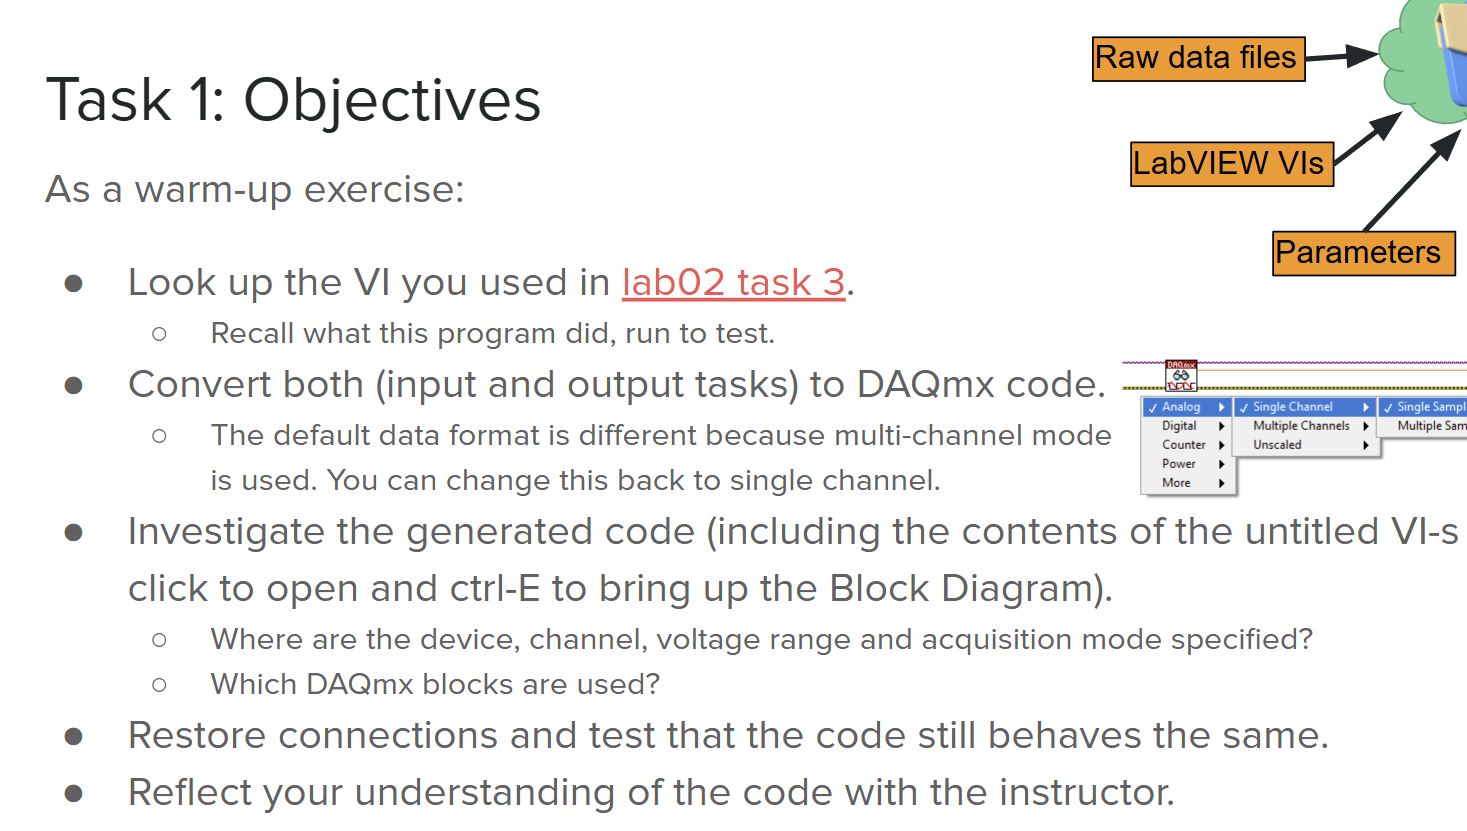

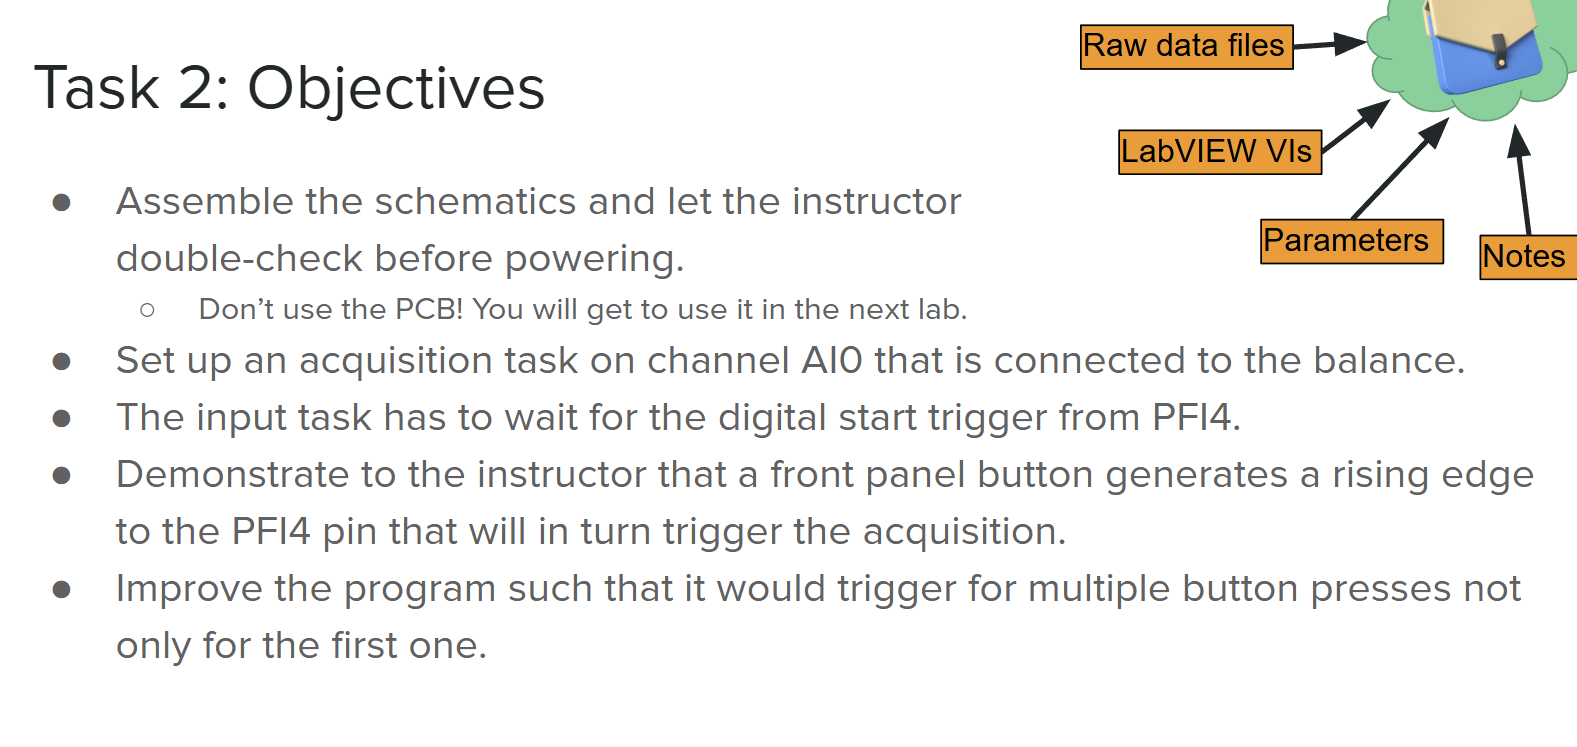

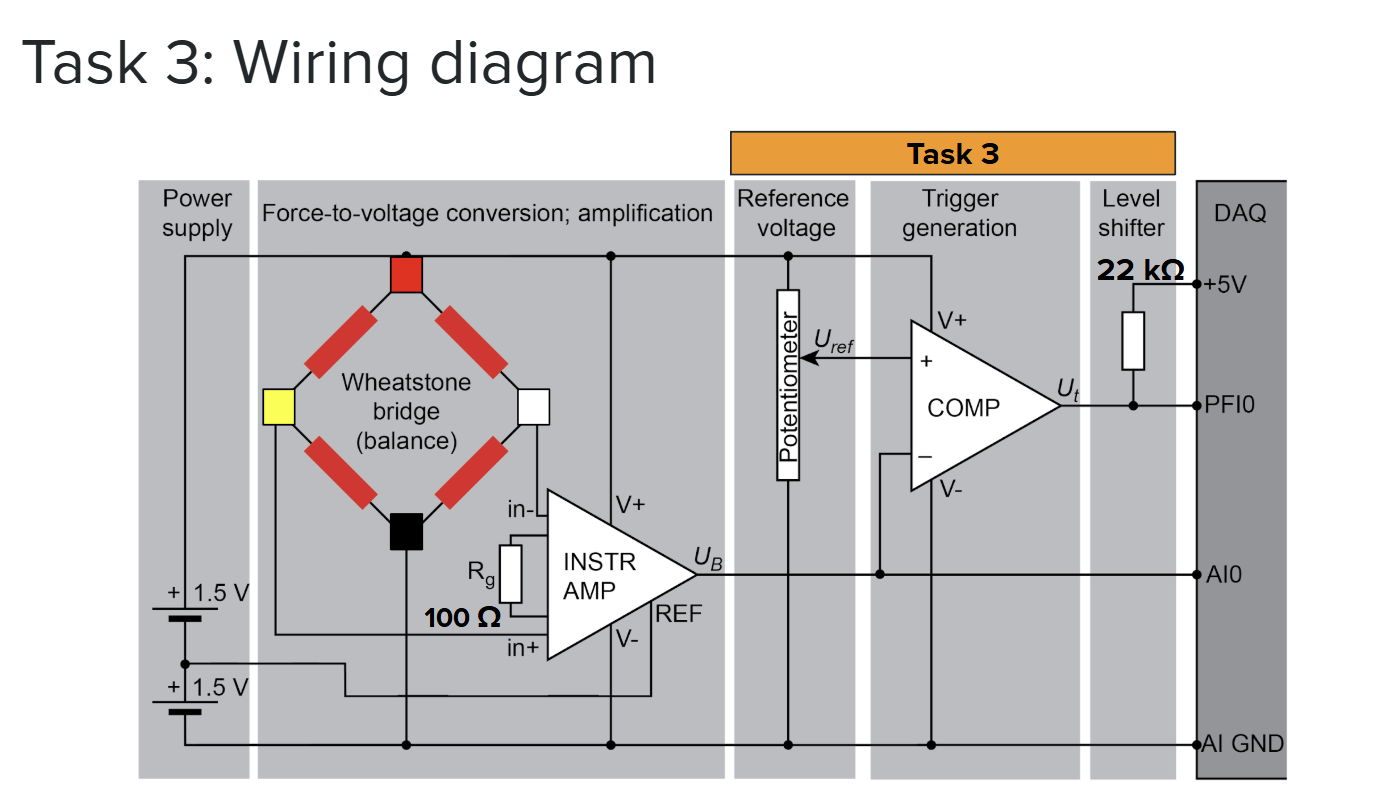
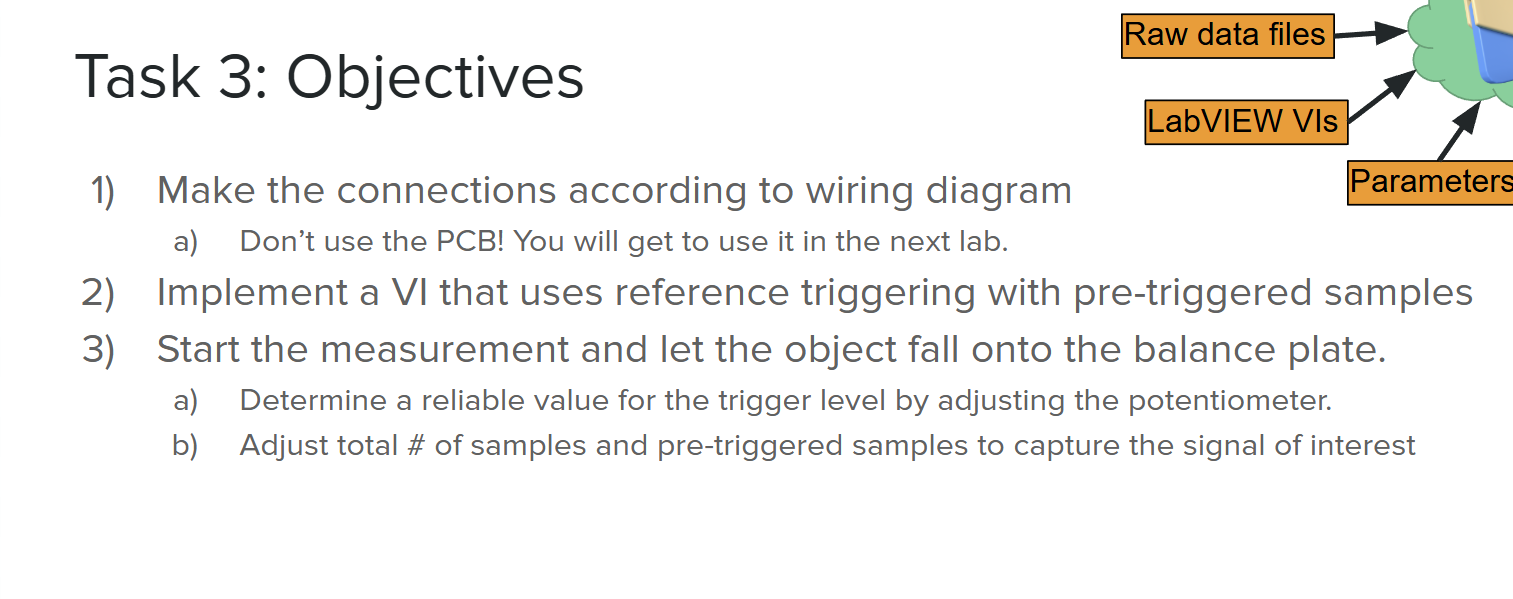